# L1-ReLU SAE Feature Steering for Zebra Unlearning in LLaVA-NeXT
#
This notebook:
1. Loads a trained L1-ReLU SAE (layer 18 of CLIP ViT-L/14-336)
2. Discovers zebra-specific features via contrastive analysis (zebra vs horse/donkey)
3. Validates features are zebra-specific and NOT generic stripes (crosswalk/shirt test)
4. Hooks into LLaVA-NeXT vision tower to zero-clamp zebra features at inference
5. Tests inference with custom images and prompts
6. Evaluates on forget (zebra) and retain (horse/donkey) datasets
7. Checks for catastrophic damage
#
**Key difference from TopK SAE version:**
- Uses L1-ReLU architecture (ReLU activation + L1 sparsity penalty) instead of TopK gating
- Smaller latent dimension: d_sae = 4096 (expansion_factor=4) instead of 32768
- Sparsity emerges naturally from L1 training — no hard top-k selection at inference
- Steering hook simply zeros features in the ReLU-activated space (no TopK manipulation needed)

## 0. Setup & Configuration

In [1]:
import subprocess
try:
    import hf_transfer
except ImportError:
    subprocess.check_call(["pip", "install", "-U", "huggingface_hub", "hf_transfer"])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 80.3 MB/s eta 0:00:00
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.3.0
    Uninstalling hf-xet-1.3.0:
      Successfully uninstalled hf-xet-1.3.0
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1


In [2]:
import os
import json
import gc
import math
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# ── Kaggle Paths ───────────────────────────────────────────────────────────────
# Upload your dataset and SAE checkpoint as a Kaggle dataset, then set:
# KAGGLE_INPUT  = "/kaggle/input/datasets/mehulagarwal0422/data-rsai"    # change to your dataset name
TRANSFER_DIR  = "/kaggle/input/datasets/mehulagarwal0422/attended-images"  # transfer test images

DATA_DIR      = "/kaggle/input/datasets/mehulagarwal0422/rsai-project-dataset/data"       # forget/ and retain/
# ── L1 SAE checkpoint path (CHANGE THIS to your uploaded L1 SAE checkpoint) ──
SAE_CKPT_PATH = "/kaggle/input/models/aaditya2801/l1-sparsity-l18/pytorch/default/1/sae_layer18_final.pt"
SAE_STATS_PATH = "/kaggle/input/models/aaditya2801/stats-file/pytorch/default/1/stats.pt"  # preprocessing stats from training

MODEL_ID        = "llava-hf/llama3-llava-next-8b-hf"
VISION_MODEL_ID = "openai/clip-vit-large-patch14-336"

# ── L1 SAE config (MUST match training in train_vision_sae_l1.py) ─────────────
D_MODEL           = 1024
EXPANSION_FACTOR  = 32
D_SAE             = D_MODEL * EXPANSION_FACTOR   # 4096
L1_COEFF          = 0.03
SAE_LAYER         = 18    # 0-indexed encoder layer
HS_INDEX          = SAE_LAYER + 1   # hidden_states index (layer N → index N+1)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.float16 if torch.cuda.is_available() else torch.float32

print(f"Device: {DEVICE}")
print(f"SAE checkpoint: {SAE_CKPT_PATH}")
print(f"Data directory: {DATA_DIR}")
print(f"SAE architecture: L1-ReLU  ({D_MODEL} → {D_SAE}, expansion={EXPANSION_FACTOR})")

Device: cuda
SAE checkpoint: /kaggle/input/models/aaditya2801/l1-sparsity-l18/pytorch/default/1/sae_layer18_final.pt
Data directory: /kaggle/input/datasets/mehulagarwal0422/rsai-project-dataset/data
SAE architecture: L1-ReLU  (1024 → 32768, expansion=32)


## 1. L1-ReLU SAE Architecture & Loading
#
The L1-ReLU SAE differs from the TopK variant:
- **Encoder**: `h = ReLU(W_enc · (x - b_dec) + b_enc)` — plain ReLU, no TopK gate
- **Decoder**: `x̂ = W_dec · h + b_dec`
- **Sparsity**: Driven by L1 penalty during training, NOT by selecting top-k activations
- **At inference**: All features with ReLU > 0 are "active" (no hard cap)

In [3]:
class L1SAE(nn.Module):
    """
    L1-ReLU Sparse Autoencoder — must match the training architecture exactly.

    This uses ReLU activation with L1 sparsity penalty (unlike TopK which uses
    hard top-k selection). The shared bias b_dec is subtracted from encoder input
    and added back in the decoder.
    """
    def __init__(self, d_model: int, d_sae: int, l1_coeff: float = 0.0):
        super().__init__()
        self.d_model   = d_model
        self.d_sae     = d_sae
        self.l1_coeff  = l1_coeff

        # Decoder (W_dec columns are feature directions)
        self.W_dec = nn.Parameter(torch.empty(d_model, d_sae))
        self.b_dec = nn.Parameter(torch.zeros(d_model))   # shared bias

        # Encoder
        self.W_enc = nn.Parameter(torch.empty(d_sae, d_model))
        self.b_enc = nn.Parameter(torch.zeros(d_sae))

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Encode to sparse latent space via ReLU (no TopK gate)."""
        x_centered = x - self.b_dec
        pre_acts   = F.linear(x_centered, self.W_enc, self.b_enc)
        return F.relu(pre_acts)   # h ∈ [0, ∞)

    def decode(self, h: torch.Tensor) -> torch.Tensor:
        """Decode from sparse latent space, add shared bias back."""
        return F.linear(h, self.W_dec, self.b_dec)

    def forward(self, x: torch.Tensor):
        h     = self.encode(x)
        x_hat = self.decode(h)
        return x_hat, h


# ── Load SAE ───────────────────────────────────────────────────────────────────
def load_l1_sae(ckpt_path, stats_path=None):
    """Load trained L1-ReLU SAE from checkpoint + preprocessing stats.

    The checkpoint may be:
    - A full checkpoint dict (from the training loop's latest/resume save)
      with keys: model_state_dict, config, etc.
    - A raw state_dict (from the final save: sae_layer{L}_final.pt)

    stats_path: path to stats.pt containing {"mean": tensor, "mean_norm": scalar}
                generated during training phase 2 (compute_stats).
    """
    ckpt = torch.load(ckpt_path, map_location="cpu")

    if "model_state_dict" in ckpt:
        state_dict = ckpt["model_state_dict"]
        config     = ckpt.get("config", {})
    else:
        state_dict = ckpt
        config     = {}

    d_model     = config.get("d_model", D_MODEL)
    d_sae       = config.get("d_sae", D_SAE)
    l1_coeff    = config.get("l1_coeff", L1_COEFF)

    sae = L1SAE(d_model, d_sae, l1_coeff)
    sae.load_state_dict(state_dict)
    sae.eval()

    # ── Load preprocessing stats from stats.pt ────────────────────────────
    mean = None
    mean_norm = None

    if stats_path and os.path.exists(stats_path):
        stats = torch.load(stats_path, map_location="cpu")
        mean = stats["mean"]                          # [d_model] tensor
        mean_norm = stats["mean_norm"]
        if isinstance(mean_norm, torch.Tensor):
            mean_norm = mean_norm.item()
        print(f"   ✅ Loaded stats from {stats_path}")
        print(f"      mean vector norm: {mean.norm().item():.4f}")
        print(f"      mean_norm: {mean_norm:.4f}")
    else:
        # Fallback: try config inside checkpoint, or companion files
        mean_norm = config.get("mean_norm", None)
        if mean_norm is None:
            latest_path = ckpt_path.replace("_final.pt", "_latest.pt")
            if os.path.exists(latest_path) and latest_path != ckpt_path:
                companion = torch.load(latest_path, map_location="cpu")
                cfg = companion.get("config", {})
                mean_norm = cfg.get("mean_norm", None)
                del companion
        if isinstance(mean_norm, torch.Tensor):
            mean_norm = mean_norm.item()
        print(f"   ⚠️ stats.pt not found at {stats_path}")
        print(f"   mean_norm from checkpoint: {mean_norm}")
        print(f"   mean vector: NOT AVAILABLE — will need on-the-fly computation")

    print(f"✅ L1-ReLU SAE loaded: {d_model} → {d_sae}  (L1 coeff={l1_coeff})")
    print(f"   Layer: {config.get('layer', SAE_LAYER)}")

    return sae, mean, mean_norm


sae, sae_mean, sae_mean_norm = load_l1_sae(SAE_CKPT_PATH, stats_path=SAE_STATS_PATH)
sae = sae.to(DEVICE)
if sae_mean is not None:
    sae_mean = sae_mean.to(DEVICE)

   ✅ Loaded stats from /kaggle/input/models/aaditya2801/stats-file/pytorch/default/1/stats.pt
      mean vector norm: 5.5016
      mean_norm: 12.1116
✅ L1-ReLU SAE loaded: 1024 → 32768  (L1 coeff=0.03)
   Layer: 18


## 2. Load Vision Model & Helper Functions

In [ ]:
from transformers import CLIPVisionModel, CLIPImageProcessor
import os

# ── HuggingFace auth (needed for gated models & faster downloads) ──
HF_TOKEN = "<HF_TOKEN>"
os.environ["HF_TOKEN"] = HF_TOKEN

# Enable faster, more robust downloads using hf_transfer
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

print("Loading CLIP ViT-L/14-336 vision encoder...")
vision_model = CLIPVisionModel.from_pretrained(
    VISION_MODEL_ID,
    torch_dtype=DTYPE,
    token=HF_TOKEN,
    low_cpu_mem_usage=True
).to(DEVICE).eval()

clip_processor = CLIPImageProcessor.from_pretrained(VISION_MODEL_ID, token=HF_TOKEN)
print("✅ Vision model loaded")

Loading CLIP ViT-L/14-336 vision encoder...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-large-patch14-336
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.final_layer_norm.weight                           | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

✅ Vision model loaded


## 2a. Verify Preprocessing Stats
#
The preprocessing stats (mean, mean_norm) were loaded from stats.pt —
the exact same stats used during SAE training.

In [5]:
print("\n" + "=" * 60)
print("PREPROCESSING STATS")
print("=" * 60)
if sae_mean is not None and sae_mean_norm is not None:
    print(f"  ✅ sae_mean:      tensor on {DEVICE}, shape={sae_mean.shape}, norm={sae_mean.norm().item():.4f}")
    print(f"  ✅ sae_mean_norm: {sae_mean_norm:.4f}")
else:
    print(f"  ❌ Stats NOT loaded — steering will not work correctly!")
    print(f"     sae_mean is None: {sae_mean is None}")
    print(f"     sae_mean_norm is None: {sae_mean_norm is None}")


PREPROCESSING STATS
  ✅ sae_mean:      tensor on cuda, shape=torch.Size([1024]), norm=5.5016
  ✅ sae_mean_norm: 12.1116


In [6]:
def load_images_from_dir(directory, prefix="", max_images=None):
    """Load images from a directory, sorted numerically."""
    img_dir = Path(directory)
    files = sorted(img_dir.glob(f"{prefix}*.png"),
                   key=lambda f: int(f.stem.split("_")[-1]))
    if max_images:
        files = files[:max_images]
    images = [Image.open(f).convert("RGB") for f in files]
    print(f"  Loaded {len(images)} images from {directory}")
    return images


def extract_sae_features(images, batch_size=8):
    """
    Pass images through CLIP → get layer activations → L1-ReLU SAE encode.

    Each image produces 576 patch activations (one per 14×14 spatial patch in
    the 336px image).  We run all 576 through the SAE, then take the max
    activation across patches to capture the strongest signal per image.

    Returns: [N_images, D_SAE] max-pooled feature activations
    """
    all_feature_maxes = []

    for i in range(0, len(images), batch_size):
        batch_imgs = images[i:i+batch_size]
        inputs = clip_processor(images=batch_imgs, return_tensors="pt")
        inputs = {k: v.to(DEVICE, dtype=DTYPE) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = vision_model(**inputs, output_hidden_states=True)
            hs = outputs.hidden_states[HS_INDEX]   # [B, 577, 1024]
            patch_acts = hs[:, 1:, :]              # drop CLS → [B, 576, 1024]

            # Preprocess: must match what was done during SAE training
            # During training: x_norm = (x - mean) / mean_norm
            acts_flat = patch_acts.reshape(-1, D_MODEL).float()
            if sae_mean is not None:
                acts_flat = (acts_flat - sae_mean) / sae_mean_norm

            # SAE encode: each 1024-dim vector → 4096-dim sparse vector
            h = sae.encode(acts_flat)              # [B*576, D_SAE]
            h = h.reshape(len(batch_imgs), 576, D_SAE)

            # Max over 576 patches → capture the strongest activations per image
            img_maxes = h.max(dim=1)[0]            # [B, D_SAE]
            all_feature_maxes.append(img_maxes.cpu())

    return torch.cat(all_feature_maxes, dim=0)     # [N, D_SAE]

## 3. Contrastive Feature Discovery
#
**Goal:** Find which SAE features encode "zebra" specifically.
#
**Method:**
1. Pass 50 zebra images → get mean SAE feature activations
2. Pass 100 horse/donkey images → get mean SAE feature activations
3. Subtract: `diff = zebra_mean - control_mean`
4. Top features (highest positive diff) = **zebra-selective features**
#
These are features that fire strongly on zebras but NOT on similar animals.

In [7]:
print("=" * 60)
print("CONTRASTIVE FEATURE DISCOVERY")
print("=" * 60)

forget_dir = os.path.join(DATA_DIR, "forget")
retain_dir = os.path.join(DATA_DIR, "retain")

forget_images = load_images_from_dir(forget_dir, prefix="forget_")
retain_images = load_images_from_dir(retain_dir, prefix="retain_")

CONTRASTIVE FEATURE DISCOVERY
  Loaded 50 images from /kaggle/input/datasets/mehulagarwal0422/rsai-project-dataset/data/forget
  Loaded 100 images from /kaggle/input/datasets/mehulagarwal0422/rsai-project-dataset/data/retain


In [8]:
print("\nExtracting SAE features for forget (zebra) images...")
zebra_features = extract_sae_features(forget_images)
print(f"  Shape: {zebra_features.shape}")

print("\nExtracting SAE features for retain (horse/donkey) images...")
control_features = extract_sae_features(retain_images)
print(f"  Shape: {control_features.shape}")


Extracting SAE features for forget (zebra) images...
  Shape: torch.Size([50, 32768])

Extracting SAE features for retain (horse/donkey) images...
  Shape: torch.Size([100, 32768])


In [9]:
# Compute difference vector
zebra_mean   = zebra_features.mean(dim=0)      # [D_SAE]
control_mean = control_features.mean(dim=0)     # [D_SAE]
diff_vector  = zebra_mean - control_mean        # [D_SAE]

# Sort by difference to find zebra-selective features
sorted_indices = torch.argsort(diff_vector, descending=True)

NUM_ZEBRA_FEATURES = 50
zebra_feature_ids = sorted_indices[:NUM_ZEBRA_FEATURES].tolist()
zebra_feature_scores = diff_vector[sorted_indices[:NUM_ZEBRA_FEATURES]].tolist()

print(f"\n{'=' * 60}")
print(f"TOP {NUM_ZEBRA_FEATURES} ZEBRA-SELECTIVE FEATURES (L1-ReLU SAE)")
print(f"{'=' * 60}")
print(f"{'Rank':>4} | {'Feature ID':>10} | {'Diff Score':>10} | {'Zebra Mean':>10} | {'Control Mean':>12}")
print("-" * 60)
for rank, (fid, score) in enumerate(zip(zebra_feature_ids[:50], zebra_feature_scores[:50])):
    z_act = zebra_mean[fid].item()
    c_act = control_mean[fid].item()
    print(f"{rank+1:4d} | {fid:10d} | {score:10.4f} | {z_act:10.4f} | {c_act:12.4f}")
print(f"... ({NUM_ZEBRA_FEATURES - 20} more)")


TOP 50 ZEBRA-SELECTIVE FEATURES (L1-ReLU SAE)
Rank | Feature ID | Diff Score | Zebra Mean | Control Mean
------------------------------------------------------------
   1 |       1207 |     0.9145 |     0.9281 |       0.0136
   2 |      17927 |     0.2833 |    18.1160 |      17.8327
   3 |       2620 |     0.2305 |     0.2497 |       0.0192
   4 |      19498 |     0.2101 |     0.2189 |       0.0088
   5 |       4484 |     0.1845 |     0.1848 |       0.0003
   6 |       5272 |     0.1129 |     0.1622 |       0.0493
   7 |      16210 |     0.0943 |     0.0994 |       0.0051
   8 |      17361 |     0.0856 |     0.0892 |       0.0036
   9 |      27270 |     0.0843 |     0.0990 |       0.0147
  10 |      16800 |     0.0780 |     0.1012 |       0.0231
  11 |      16511 |     0.0764 |     0.1370 |       0.0605
  12 |      27718 |     0.0747 |     0.0838 |       0.0091
  13 |      10528 |     0.0744 |     0.1017 |       0.0273
  14 |       4259 |     0.0742 |     0.0750 |       0.0008
  15 | 

In [10]:
# Sparsity analysis — unique to L1 SAE: check the natural L0 sparsity
with torch.no_grad():
    zebra_l0 = (zebra_features > 0).float().sum(dim=-1).mean().item()
    control_l0 = (control_features > 0).float().sum(dim=-1).mean().item()
print(f"\n📊 L1-ReLU SAE Sparsity Analysis:")
print(f"   Average L0 (active features) on zebra images:   {zebra_l0:.1f} / {D_SAE}")
print(f"   Average L0 (active features) on control images: {control_l0:.1f} / {D_SAE}")
print(f"   Sparsity ratio (zebra):   {1 - zebra_l0/D_SAE:.2%}")
print(f"   Sparsity ratio (control): {1 - control_l0/D_SAE:.2%}")


📊 L1-ReLU SAE Sparsity Analysis:
   Average L0 (active features) on zebra images:   13303.6 / 32768
   Average L0 (active features) on control images: 14186.1 / 32768
   Sparsity ratio (zebra):   59.40%
   Sparsity ratio (control): 56.71%


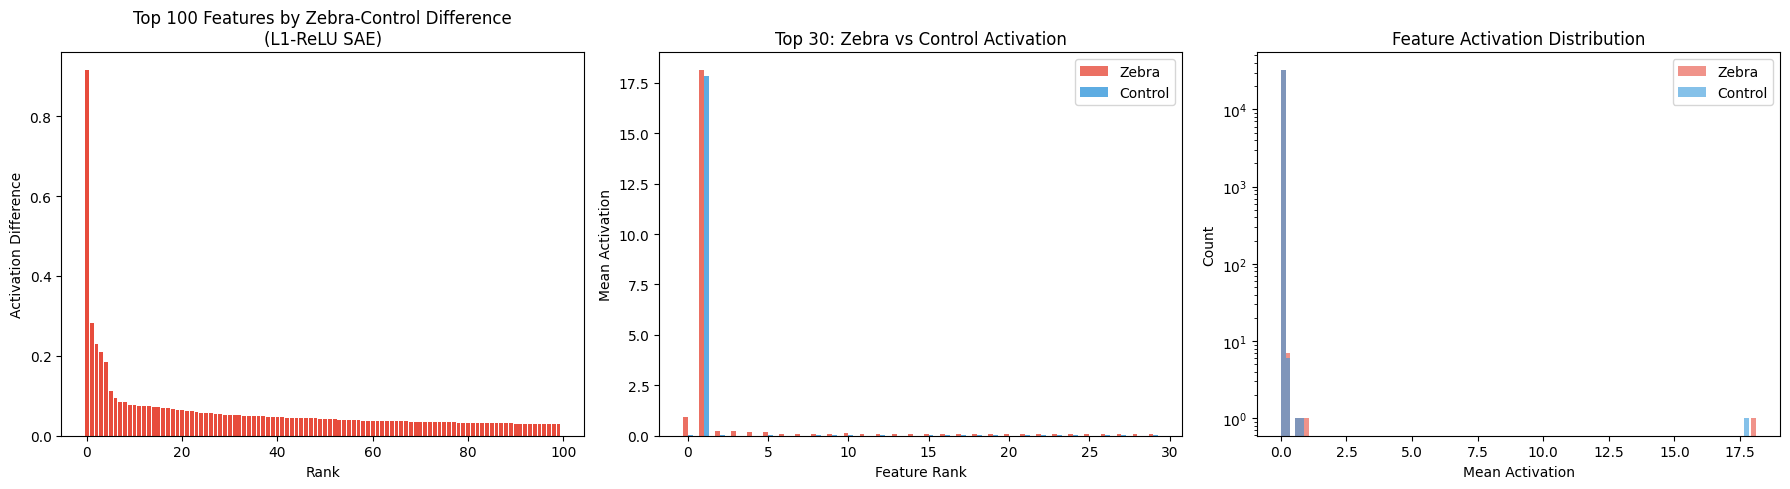

Saved: contrastive_features_l1.png


In [11]:
# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
top_diffs = diff_vector[sorted_indices[:100]].numpy()
ax.bar(range(100), top_diffs, color=['#e74c3c' if d > 0 else '#3498db' for d in top_diffs])
ax.set_xlabel("Rank")
ax.set_ylabel("Activation Difference")
ax.set_title("Top 100 Features by Zebra-Control Difference\n(L1-ReLU SAE)")
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)

ax = axes[1]
top_ids = sorted_indices[:30].numpy()
ax.bar(np.arange(30) - 0.15, zebra_mean[top_ids].numpy(), 0.3,
       label='Zebra', color='#e74c3c', alpha=0.8)
ax.bar(np.arange(30) + 0.15, control_mean[top_ids].numpy(), 0.3,
       label='Control', color='#3498db', alpha=0.8)
ax.set_xlabel("Feature Rank")
ax.set_ylabel("Mean Activation")
ax.set_title("Top 30: Zebra vs Control Activation")
ax.legend()

ax = axes[2]
ax.hist(zebra_mean.numpy(), bins=100, alpha=0.6, label='Zebra', color='#e74c3c')
ax.hist(control_mean.numpy(), bins=100, alpha=0.6, label='Control', color='#3498db')
ax.set_xlabel("Mean Activation")
ax.set_ylabel("Count")
ax.set_title("Feature Activation Distribution")
ax.legend()
ax.set_yscale('log')

plt.tight_layout()
plt.savefig("contrastive_features_l1.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: contrastive_features_l1.png")

## 4. Transfer Test: Are These Features Zebra-Specific?
#
**Why this matters:** If the features we're clamping fire on crosswalks,
striped shirts, and piano keys, then we're removing "stripes in general" —
NOT "zebra" specifically.
#
**What we want to see:**
- Zebra images → high activation on these features ✅
- Crosswalk / striped shirt / piano → LOW activation ✅ (zebra-specific)
- If crosswalk fires high → ⚠️ we need to refine our feature selection

In [12]:
transfer_image_files = {
    "crosswalk_1":    "crosswalk_1.png",
    "crosswalk_2":    "crosswalk_2.png",
    "striped_shirt":  "striped_shirt.png",
    "piano_keys":     "piano_keys.png",
}

print("Loading transfer test images...")
transfer_images = {}
for name, filename in transfer_image_files.items():
    path = os.path.join(TRANSFER_DIR, filename)
    if os.path.exists(path):
        transfer_images[name] = Image.open(path).convert("RGB")
        print(f"  ✅ {name} ({path})")
    else:
        print(f"  ⚠️ {name} not found at {path}, skipping")

# Fallback: generate synthetic stripe images if no files found
if not transfer_images:
    print("\n  No transfer images found. Creating synthetic patterns...")
    crosswalk = Image.new("RGB", (336, 336), "gray")
    px = crosswalk.load()
    for y in range(336):
        for x in range(336):
            px[x, y] = (255, 255, 255) if (y // 30) % 2 == 0 else (40, 40, 40)
    transfer_images["synthetic_stripes_h"] = crosswalk

    vert = Image.new("RGB", (336, 336), "gray")
    px = vert.load()
    for y in range(336):
        for x in range(336):
            px[x, y] = (255, 255, 255) if (x // 20) % 2 == 0 else (0, 0, 0)
    transfer_images["synthetic_stripes_v"] = vert

    solid = Image.new("RGB", (336, 336), (100, 150, 100))
    transfer_images["solid_green_control"] = solid

Loading transfer test images...
  ✅ crosswalk_1 (/kaggle/input/datasets/mehulagarwal0422/attended-images/crosswalk_1.png)
  ✅ crosswalk_2 (/kaggle/input/datasets/mehulagarwal0422/attended-images/crosswalk_2.png)
  ✅ striped_shirt (/kaggle/input/datasets/mehulagarwal0422/attended-images/striped_shirt.png)
  ✅ piano_keys (/kaggle/input/datasets/mehulagarwal0422/attended-images/piano_keys.png)


In [13]:
if transfer_images:
    transfer_list = list(transfer_images.values())
    transfer_names = list(transfer_images.keys())
    transfer_features = extract_sae_features(transfer_list, batch_size=4)

    print(f"\n{'=' * 70}")
    print("TRANSFER TEST: Do Zebra Features Fire on Non-Zebra Stripes?")
    print(f"{'=' * 70}")

    zebra_feat_tensor = torch.tensor(zebra_feature_ids[:20])

    print(f"\n{'Image':>25} | {'Zebra Feat Act':>15} | {'All Feat Act':>13} | {'Verdict'}")
    print("-" * 75)

    zebra_baseline = zebra_mean[zebra_feat_tensor].mean().item()
    control_baseline = control_mean[zebra_feat_tensor].mean().item()
    print(f"{'[ZEBRA IMAGES]':>25} | {zebra_baseline:15.4f} | {zebra_mean.mean().item():13.4f} | baseline")
    print(f"{'[HORSE/DONKEY]':>25} | {control_baseline:15.4f} | {control_mean.mean().item():13.4f} | baseline")
    print("-" * 75)

    for name, feat_vec in zip(transfer_names, transfer_features):
        z_feat_act = feat_vec[zebra_feat_tensor].mean().item()
        all_feat_act = feat_vec.mean().item()
        ratio = z_feat_act / (zebra_baseline + 1e-8)
        if ratio > 0.5:
            verdict = "⚠️ HIGH — generic stripe feature!"
        elif ratio > 0.3:
            verdict = "⚠️ moderate — partially generic"
        else:
            verdict = "✅ low — zebra-specific (good)"
        print(f"{name:>25} | {z_feat_act:15.4f} | {all_feat_act:13.4f}")

    print(f"\nInterpretation:")
    # print(f"  ✅ = Feature is ZEBRA-SPECIFIC → safe to clamp without collateral damage")
    # print(f"  ⚠️ = Feature is GENERIC STRIPES → clamping it would also affect crosswalks etc.")


TRANSFER TEST: Do Zebra Features Fire on Non-Zebra Stripes?

                    Image |  Zebra Feat Act |  All Feat Act | Verdict
---------------------------------------------------------------------------
           [ZEBRA IMAGES] |          1.0574 |        0.0090 | baseline
           [HORSE/DONKEY] |          0.9078 |        0.0107 | baseline
---------------------------------------------------------------------------
              crosswalk_1 |          0.9352 |        0.0073
              crosswalk_2 |          0.7833 |        0.0118
            striped_shirt |          0.8894 |        0.0065
               piano_keys |          0.8605 |        0.0047

Interpretation:


## 5. Load Full LLaVA-NeXT & Define Steering Hook
#
**L1-ReLU SAE Steering Hook:**
Unlike the TopK SAE where we need to manipulate pre-activations before the
top-k selection, the L1-ReLU SAE uses plain ReLU. This means:
1. Encode the activation through the SAE (ReLU gives sparse h)
2. Zero out the targeted feature indices in h
3. Decode back — the model never sees zebra information
#
We also support negative clamping: driving features to a large negative
value before ReLU, which has the same zero-output effect but lets us
compare strategies.

In [14]:
print("=" * 60)
print("LOADING FULL LLaVA-NeXT MODEL")
print("=" * 60)

from transformers import LlavaNextForConditionalGeneration, LlavaNextProcessor

# Free standalone vision model to make GPU room
del vision_model
gc.collect()
torch.cuda.empty_cache()

llava_model = LlavaNextForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    low_cpu_mem_usage=True,
    device_map="auto",
    token=HF_TOKEN,
)
llava_processor = LlavaNextProcessor.from_pretrained(MODEL_ID, token=HF_TOKEN)
llava_model.eval()
print("✅ LLaVA-NeXT loaded")

LOADING FULL LLaVA-NeXT MODEL


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

...

The image processor of type `LlavaNextImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/434 [00:00<?, ?B/s]

✅ LLaVA-NeXT loaded


In [15]:
def create_steering_hook(sae_model, feature_ids_to_steer, mean_vec, mean_norm_val, alpha=-5.0):
    """
    Forward hook for the vision encoder layer (Additive Steering version).

    Bypasses the SAE encoder entirely during inference. We extract the
    dictionary vectors (W_dec) for the target features and add them directly
    to the original hidden states, scaled by the suppression coefficient (alpha).
    """
    with torch.no_grad():
        # Extract W_dec columns for target features -> [d_model, num_features]
        # W_dec is shape [d_model, d_sae]
        target_dirs = sae_model.W_dec[:, feature_ids_to_steer]

        # Combine them into a single steering direction vector [d_model]
        steering_vec_norm = target_dirs.sum(dim=1)

        # Note: Additive steering is translation-invariant to the centering 
        # (mean_vec), so we don't need to subtract/add mean_vec here. 
        # We only need to scale it by the norm to match the original space.
        if mean_norm_val is not None:
            steering_vec = steering_vec_norm * mean_norm_val
        else:
            steering_vec = steering_vec_norm # Fallback if stats missing

    _stats = {"calls": 0, "total_l2_change": 0.0}

    def hook_fn(module, input, output):
        hidden_states = output[0] if isinstance(output, tuple) else output
        original_dtype = hidden_states.dtype

        with torch.no_grad():
            # Additive Steering: h_steered = h_original + (alpha * W_dec * norm)
            # Broadcasting automatically handles [B, Seq, D_MODEL] + [D_MODEL]
            
            if mean_norm_val is not None:
                # Static scaling
                steered = hidden_states + (alpha * steering_vec.to(hidden_states.device))
            else:
                # Dynamic scaling (if trained with per-token norms)
                norms = hidden_states.norm(dim=-1, keepdim=True).clamp(min=1e-8)
                steered = hidden_states + (alpha * steering_vec.to(hidden_states.device) * norms)

        # Diagnostics
        _stats["calls"] += 1
        l2_change = (steered - hidden_states).norm(dim=-1).mean().item()
        _stats["total_l2_change"] += l2_change
        if _stats["calls"] == 1:
            print(f"   [hook] Activation L2 change: {l2_change:.4f}")

        steered = steered.to(original_dtype)
        if isinstance(output, tuple):
            return (steered,) + output[1:]
        return steered

    hook_fn._stats = _stats
    return hook_fn

def get_target_layer(model, layer_idx):
    """
    Specifically targets the vision model nested inside the Llama/LLaVA structure.
    """
    if hasattr(model, 'model') and hasattr(model.model, 'vision_tower'):
        return model.model.vision_tower.vision_model.encoder.layers[layer_idx]
    if hasattr(model, 'vision_tower'):
        return model.vision_tower.vision_model.encoder.layers[layer_idx]
    raise AttributeError("Could not locate model.model.vision_tower. Ensure you passed 'llava_model'.")

def run_vlm_inference(model, processor, image, question, max_tokens=128):
    conversation = [
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": question},
        ]}
    ]
    prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)
    inputs = processor(images=image, text=prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            pad_token_id=processor.tokenizer.eos_token_id
        )

    generated = output_ids[0][inputs["input_ids"].shape[1]:]
    return processor.decode(generated, skip_special_tokens=True).strip()

In [16]:
# ── DIAGNOSTIC: Verify SAE hook changes activations ──────────────────────────

print("=" * 60)
print("HOOK DIAGNOSTIC")
print("=" * 60)

# Load a test image
_diag_img_path = os.path.join(DATA_DIR, "forget", "forget_2.png")
_diag_img = Image.open(_diag_img_path).convert("RGB")
_diag_prompt = "Describe the image."

# Collect activations WITH and WITHOUT hook using a capture hook
_activations = {}

def _capture_hook(name):
    def fn(module, input, output):
        hs = output[0] if isinstance(output, tuple) else output
        _activations[name] = hs.detach().cpu().float()
    return fn

_target = get_target_layer(llava_model, SAE_LAYER)

# Capture WITHOUT steering
_h1 = _target.register_forward_hook(_capture_hook("before"))
_ = run_vlm_inference(llava_model, llava_processor, _diag_img, _diag_prompt)
_h1.remove()

# Capture WITH steering (Additive Steering, alpha = -5.0)
_steer_fn = create_steering_hook(sae, zebra_feature_ids[:50], sae_mean, sae_mean_norm, alpha=-5.0)
_h2 = _target.register_forward_hook(_steer_fn)
_h3 = _target.register_forward_hook(_capture_hook("after"))
_ = run_vlm_inference(llava_model, llava_processor, _diag_img, _diag_prompt)
_h2.remove()
_h3.remove()

if "before" in _activations and "after" in _activations:
    diff = (_activations["after"] - _activations["before"]).norm(dim=-1)
    print(f"Max L2 change across tokens:  {diff.max().item():.4f}")
    print(f"Mean L2 change across tokens: {diff.mean().item():.4f}")
    print(f"Tokens with >0.01 change:     {(diff > 0.01).sum().item()} / {diff.numel()}")
    if diff.mean().item() < 1e-6:
        print("\n⚠️  WARNING: Hook is NOT changing activations!")
        print("   Possible causes:")
        print("   1. sae_mean / sae_mean_norm are None → SAE gets unnormalized inputs")
        print("      → features don't match zebra_feature_ids")
        print("   2. zebra_feature_ids are not active for this image")
        print("   3. get_target_layer() is returning the wrong layer")
    else:
        print("\n✅ Hook is working — activations are being modified")
else:
    print("❌ Could not capture activations — check get_target_layer()")

HOOK DIAGNOSTIC
   [hook] Activation L2 change: 665.2855
Max L2 change across tokens:  665.3184
Mean L2 change across tokens: 665.2853
Tokens with >0.01 change:     2885 / 2885

✅ Hook is working — activations are being modified


## 6. Interactive Inference — Test With Your Own Images
#
Set the image path and prompt below, then run the cell.
It shows the model's response WITH and WITHOUT zebra feature clamping.

In [17]:
# ── SET THESE ──────────────────────────────────────────────────────────────────
TEST_IMAGE_PATH = os.path.join(DATA_DIR, "forget", "forget_2.png")
TEST_PROMPT     = "What animal is shown in this image? Just give in one sentence"

CLAMP_TOP_N     = 500
NEG_CLAMP_VALUE = -5.0
# ───────────────────────────────────────────────────────────────────────────────

# ── Pre-flight check ─────────────────────────────────────────────────────────
print("=" * 60)
print("PRE-FLIGHT CHECKS")
print("=" * 60)
print(f"sae_mean loaded:      {sae_mean is not None}")
print(f"sae_mean_norm loaded: {sae_mean_norm is not None}")
if sae_mean_norm is not None:
    print(f"sae_mean_norm value:  {sae_mean_norm:.4f}")
print(f"Top zebra feature IDs (first 5): {zebra_feature_ids[:5]}")
print(f"Top zebra feature scores (first 5): {[f'{s:.3f}' for s in zebra_feature_scores[:5]]}")
print(f"CLAMP_TOP_N: {CLAMP_TOP_N} features")
print(f"NEG_CLAMP_VALUE: {NEG_CLAMP_VALUE}")
print(f"SAE type: L1-ReLU (d_sae={D_SAE})")
print()

test_image = Image.open(TEST_IMAGE_PATH).convert("RGB")

print(f"Image: {TEST_IMAGE_PATH}")
print(f"Prompt: {TEST_PROMPT}")
print(f"Clamping top {CLAMP_TOP_N} zebra features\n")

target_layer = get_target_layer(llava_model, SAE_LAYER)

# --- 1. WITHOUT steering ---
print("🔵 WITHOUT steering:")
response_normal = run_vlm_inference(llava_model, llava_processor, test_image, TEST_PROMPT)
print(f"   {response_normal}\n")

# --- 2. WITH MILD Additive Steering ---
hook_fn_mild = create_steering_hook(
    sae, zebra_feature_ids[:CLAMP_TOP_N], sae_mean, sae_mean_norm,
    alpha=-2.0
)
hook_handle = target_layer.register_forward_hook(hook_fn_mild)
try:
    print(f"🟡 WITH steering (MILD Additive, alpha = -2.0):")
    response_mild = run_vlm_inference(llava_model, llava_processor, test_image, TEST_PROMPT)
    print(f"   {response_mild}")
    avg_l2 = hook_fn_mild._stats['total_l2_change'] / max(hook_fn_mild._stats['calls'], 1)
    print(f"   [Avg L2 change per token: {avg_l2:.4f}]\n")
finally:
    hook_handle.remove()

# --- 3. WITH AGGRESSIVE Additive Steering ---
hook_fn_agg = create_steering_hook(
    sae, zebra_feature_ids[:CLAMP_TOP_N], sae_mean, sae_mean_norm,
    alpha=-10.0
)
hook_handle = target_layer.register_forward_hook(hook_fn_agg)
try:
    print(f"🔴 WITH steering (AGGRESSIVE Additive, alpha = -10.0):")
    response_agg = run_vlm_inference(llava_model, llava_processor, test_image, TEST_PROMPT)
    print(f"   {response_agg}")
    avg_l2_agg = hook_fn_agg._stats['total_l2_change'] / max(hook_fn_agg._stats['calls'], 1)
    print(f"   [Avg L2 change per token: {avg_l2_agg:.4f}]")
finally:
    hook_handle.remove()

PRE-FLIGHT CHECKS
sae_mean loaded:      True
sae_mean_norm loaded: True
sae_mean_norm value:  12.1116
Top zebra feature IDs (first 5): [1207, 17927, 2620, 19498, 4484]
Top zebra feature scores (first 5): ['0.914', '0.283', '0.231', '0.210', '0.185']
CLAMP_TOP_N: 500 features
NEG_CLAMP_VALUE: -5.0
SAE type: L1-ReLU (d_sae=32768)

Image: /kaggle/input/datasets/mehulagarwal0422/rsai-project-dataset/data/forget/forget_2.png
Prompt: What animal is shown in this image? Just give in one sentence
Clamping top 500 zebra features

🔵 WITHOUT steering:
   The image shows a zebra standing in a field.

🟡 WITH steering (MILD Additive, alpha = -2.0):
   [hook] Activation L2 change: 266.1141
   There is no animal shown in the image.
   [Avg L2 change per token: 266.1141]

🔴 WITH steering (AGGRESSIVE Additive, alpha = -10.0):
   [hook] Activation L2 change: 1330.5709
   There is no animal shown in this image.
   [Avg L2 change per token: 1330.5709]


In [18]:
# ── Test on a retain image (horse) ───────────────────────────────────────────
TEST_IMAGE_PATH_2 = os.path.join(DATA_DIR, "retain", "retain_0.png")
TEST_PROMPT_2     = "What animal is shown in this image?"

test_image_2 = Image.open(TEST_IMAGE_PATH_2).convert("RGB")

print(f"\nImage: {TEST_IMAGE_PATH_2}")
print(f"Prompt: {TEST_PROMPT_2}\n")

print("🔵 WITHOUT steering:")
resp_normal_2 = run_vlm_inference(llava_model, llava_processor, test_image_2, TEST_PROMPT_2)
print(f"   {resp_normal_2}\n")

# Mild Additive
target_layer = get_target_layer(llava_model, SAE_LAYER)
hook_fn_mild = create_steering_hook(
    sae, zebra_feature_ids[:CLAMP_TOP_N], sae_mean, sae_mean_norm,
    alpha=-2.0
)
hook_handle = target_layer.register_forward_hook(hook_fn_mild)
try:
    print("🟡 WITH steering (MILD Additive, alpha=-2.0):")
    resp_mild_2 = run_vlm_inference(llava_model, llava_processor, test_image_2, TEST_PROMPT_2)
    print(f"   {resp_mild_2}\n")
finally:
    hook_handle.remove()

# Aggressive Additive
target_layer = get_target_layer(llava_model, SAE_LAYER)
hook_fn_agg = create_steering_hook(
    sae, zebra_feature_ids[:CLAMP_TOP_N], sae_mean, sae_mean_norm,
    alpha=-10.0
)
hook_handle = target_layer.register_forward_hook(hook_fn_agg)
try:
    print(f"🔴 WITH steering (AGGRESSIVE Additive, alpha=-10.0):")
    resp_agg_2 = run_vlm_inference(llava_model, llava_processor, test_image_2, TEST_PROMPT_2)
    print(f"   {resp_agg_2}")
finally:
    hook_handle.remove()


Image: /kaggle/input/datasets/mehulagarwal0422/rsai-project-dataset/data/retain/retain_0.png
Prompt: What animal is shown in this image?

🔵 WITHOUT steering:
   The image shows a horse.

🟡 WITH steering (MILD Additive, alpha=-2.0):
   [hook] Activation L2 change: 266.1141
   There is no animal shown in the image. It appears to be a photo of a location, possibly a park or a garden, with a focus on the ground and the surrounding area.

🔴 WITH steering (AGGRESSIVE Additive, alpha=-10.0):
   [hook] Activation L2 change: 1330.5709
   There is no animal shown in this image.


## 7. Evaluation on Forget & Retain Datasets

In [19]:
# Load dataset manifest
manifest_path = os.path.join(DATA_DIR, "dataset_manifest.json")
with open(manifest_path) as f:
    manifest = json.load(f)

forget_qa = manifest["forget_qa_pairs"]
retain_qa = manifest["retain_qa_template"]
retain_labels = manifest["retain_labels"]

print(f"Forget QA pairs: {len(forget_qa)}")
print(f"Retain QA template: {len(retain_qa)}")
print(f"Retain images: {len(retain_labels)}")

Forget QA pairs: 3
Retain QA template: 3
Retain images: 100


In [20]:
def evaluate_forget_accuracy(model, processor, images, qa_pairs, num_images=50):
    """
    Evaluate how well the model identifies zebras in forget images.
    Low FA after steering = successful unlearning.
    """
    results = []
    for i in tqdm(range(min(num_images, len(images))), desc="Forget eval"):
        img = images[i]
        for qa in qa_pairs:
            response = run_vlm_inference(model, processor, img, qa["question"])
            gt = qa["ground_truth"].lower()
            correct = gt in response.lower()
            results.append({
                "image": f"forget_{i}", "question": qa["question"],
                "ground_truth": qa["ground_truth"], "response": response,
                "correct": correct,
            })
    accuracy = sum(r["correct"] for r in results) / len(results) if results else 0
    return accuracy, results


def evaluate_retain_accuracy(model, processor, images, qa_template,
                             labels, num_images=100):
    """
    Evaluate model accuracy on retain images (horses/donkeys).
    High RA after steering = no catastrophic damage.
    """
    results = []
    for i in tqdm(range(min(num_images, len(images))), desc="Retain eval"):
        img = images[i]
        animal = labels[i]
        for qa in qa_template:
            gt = qa["ground_truth"].replace("{{animal}}", animal)
            response = run_vlm_inference(model, processor, img, qa["question"])
            resp_lower = response.lower()
            correct = (gt.lower() in resp_lower or
                       animal.lower() in resp_lower or
                       "horse" in resp_lower or "donkey" in resp_lower)
            results.append({
                "image": f"retain_{i}", "question": qa["question"],
                "ground_truth": gt, "response": response,
                "correct": correct,
            })
    accuracy = sum(r["correct"] for r in results) / len(results) if results else 0
    return accuracy, results

### 7a. Steered Evaluation — Forget Set (Zebras)

In [21]:
print("=" * 60)
print("STEERED EVALUATION ON FORGET SET (ZEBRAS)")
print("=" * 60)

CLAMP_COUNTS  = [20]
ALPHAS        = [-2.0, -5.0, -10.0]   # Test different steering strengths
NUM_EVAL      = 10  

summary_forget = {}

for n_clamp in CLAMP_COUNTS:
    features_to_clamp = zebra_feature_ids[:n_clamp]
    summary_forget[n_clamp] = {}

    for alpha_val in ALPHAS:
        print(f"\n── {n_clamp} features | Alpha = {alpha_val} ──")

        target_layer = get_target_layer(llava_model, SAE_LAYER)
        hook_fn = create_steering_hook(
            sae, features_to_clamp, sae_mean, sae_mean_norm,
            alpha=alpha_val
        )
        hook_handle = target_layer.register_forward_hook(hook_fn)

        try:
            fa, fa_results = evaluate_forget_accuracy(
                llava_model, llava_processor, forget_images, forget_qa,
                num_images=NUM_EVAL
            )
            summary_forget[n_clamp][alpha_val] = fa
            print(f"  Forget Accuracy (alpha={alpha_val}): {fa:.2%}")

            for r in fa_results[:2]:
                status = "✅" if r["correct"] else "❌"
                print(f"    {status} Q: {r['question'][:50]}...")
                print(f"       A: {r['response'][:80]}")
        finally:
            hook_handle.remove()

# Print comparison table
print(f"\n{'=' * 65}")
print("FORGET ACCURACY COMPARISON (lower = better unlearning)")
print(f"{'=' * 65}")
print(f"{'N features':>12} | {'Alpha = -2.0':>14} | {'Alpha = -5.0':>14} | {'Alpha = -10.0':>14}")
print("-" * 65)
for n_clamp in CLAMP_COUNTS:
    a1 = summary_forget[n_clamp].get(-2.0, float('nan'))
    a2 = summary_forget[n_clamp].get(-5.0, float('nan'))
    a3 = summary_forget[n_clamp].get(-10.0, float('nan'))
    print(f"{n_clamp:>12} | {a1:>13.2%} | {a2:>13.2%} | {a3:>13.2%}")

STEERED EVALUATION ON FORGET SET (ZEBRAS)

── 20 features | Alpha = -2.0 ──


Forget eval:   0%|          | 0/10 [00:00<?, ?it/s]

   [hook] Activation L2 change: 155.9333
  Forget Accuracy (alpha=-2.0): 0.00%
    ❌ Q: What animal is shown in this image?...
       A: There is no animal shown in this image. It appears to be a photograph of a perso
    ❌ Q: Describe the pattern/texture of the animal....
       A: The image you've provided is a photograph of a person taking a selfie. The perso

── 20 features | Alpha = -5.0 ──


Forget eval:   0%|          | 0/10 [00:00<?, ?it/s]

   [hook] Activation L2 change: 389.8332
  Forget Accuracy (alpha=-5.0): 6.67%
    ❌ Q: What animal is shown in this image?...
       A: 
    ❌ Q: Describe the pattern/texture of the animal....
       A: 

── 20 features | Alpha = -10.0 ──


Forget eval:   0%|          | 0/10 [00:00<?, ?it/s]

   [hook] Activation L2 change: 779.6664
  Forget Accuracy (alpha=-10.0): 0.00%
    ❌ Q: What animal is shown in this image?...
       A: 
    ❌ Q: Describe the pattern/texture of the animal....
       A: 

FORGET ACCURACY COMPARISON (lower = better unlearning)
  N features |   Alpha = -2.0 |   Alpha = -5.0 |  Alpha = -10.0
-----------------------------------------------------------------
          20 |         0.00% |         6.67% |         0.00%


### 7b. Steered Evaluation — Retain Set (Horses/Donkeys)

In [22]:
print("\n" + "=" * 60)
print("STEERED EVALUATION ON RETAIN SET (HORSES/DONKEYS)")
print("=" * 60)

# Use best clamp count from above
BEST_CLAMP    = 20  # adjust based on results above
ALPHAS        = [-2.0, -5.0, -10.0]

summary_retain = {}

for alpha_val in ALPHAS:
    print(f"\n── {BEST_CLAMP} features | Alpha = {alpha_val} ──")

    target_layer = get_target_layer(llava_model, SAE_LAYER)
    hook_fn = create_steering_hook(
        sae, zebra_feature_ids[:BEST_CLAMP], sae_mean, sae_mean_norm,
        alpha=alpha_val
    )
    hook_handle = target_layer.register_forward_hook(hook_fn)

    try:
        ra, ra_results = evaluate_retain_accuracy(
            llava_model, llava_processor, retain_images, retain_qa,
            retain_labels, num_images=NUM_EVAL
        )
        summary_retain[alpha_val] = ra
        print(f"  Retain Accuracy (alpha={alpha_val}, {BEST_CLAMP} features): {ra:.2%}")

        for r in ra_results[:3]:
            status = "✅" if r["correct"] else "❌"
            print(f"    {status} Q: {r['question'][:50]}...")
            print(f"       A: {r['response'][:80]}")
    finally:
        hook_handle.remove()

# Print comparison table
print(f"\n{'=' * 45}")
print("RETAIN ACCURACY COMPARISON (higher = less damage)")
print(f"{'=' * 45}")
print(f"{'Alpha':>12} | {'Retain Accuracy':>16}")
print("-" * 32)
for alpha_val in ALPHAS:
    ra = summary_retain.get(alpha_val, float('nan'))
    print(f"{alpha_val:>12} | {ra:>15.2%}")


STEERED EVALUATION ON RETAIN SET (HORSES/DONKEYS)

── 20 features | Alpha = -2.0 ──


Retain eval:   0%|          | 0/10 [00:00<?, ?it/s]

   [hook] Activation L2 change: 155.9333
  Retain Accuracy (alpha=-2.0, 20 features): 33.33%
    ❌ Q: What animal is shown in this image?...
       A: There is no animal shown in this image. It appears to be a photograph of a perso
    ❌ Q: Describe the pattern/texture of the animal....
       A: The image you've provided is a photograph of a person taking a selfie. The perso
    ✅ Q: Is this a zebra or a horse?...
       A: This is a horse.

── 20 features | Alpha = -5.0 ──


Retain eval:   0%|          | 0/10 [00:00<?, ?it/s]

   [hook] Activation L2 change: 389.8332
  Retain Accuracy (alpha=-5.0, 20 features): 0.00%
    ❌ Q: What animal is shown in this image?...
       A: 
    ❌ Q: Describe the pattern/texture of the animal....
       A: 
    ❌ Q: Is this a zebra or a horse?...
       A: 

── 20 features | Alpha = -10.0 ──


Retain eval:   0%|          | 0/10 [00:00<?, ?it/s]

   [hook] Activation L2 change: 779.6664
  Retain Accuracy (alpha=-10.0, 20 features): 0.00%
    ❌ Q: What animal is shown in this image?...
       A: 
    ❌ Q: Describe the pattern/texture of the animal....
       A: 
    ❌ Q: Is this a zebra or a horse?...
       A: 

RETAIN ACCURACY COMPARISON (higher = less damage)
       Alpha |  Retain Accuracy
--------------------------------
        -2.0 |          33.33%
        -5.0 |           0.00%
       -10.0 |           0.00%


## 8. Catastrophic Damage Check
#
Test the steered model on general vision questions (not animal-specific)
to make sure we haven't broken the model's general understanding.

In [23]:
print("=" * 60)
print("CATASTROPHIC DAMAGE CHECK")
print("=" * 60)

general_questions = [
    "Describe what you see in this image in detail.",
    "What colors are most prominent in this image?",
    "Is this image taken indoors or outdoors?",
]

ALPHAS = [-2.0, -5.0, -10.0]

for alpha_val in ALPHAS:
    print(f"\n{'─' * 50}")
    print(f"Alpha: {alpha_val}")
    print(f"{'─' * 50}")

    target_layer = get_target_layer(llava_model, SAE_LAYER)
    hook_fn = create_steering_hook(
        sae, zebra_feature_ids[:BEST_CLAMP], sae_mean, sae_mean_norm,
        alpha=alpha_val
    )
    hook_handle = target_layer.register_forward_hook(hook_fn)

    try:
        for i in range(3):
            img = retain_images[i * 10]  # retain_0, retain_10, retain_20
            q = general_questions[i]
            response = run_vlm_inference(llava_model, llava_processor, img, q)
            print(f"\n  Image: retain_{i*10}.png")
            print(f"  Q: {q}")
            print(f"  A: {response[:150]}")
    finally:
        hook_handle.remove()

CATASTROPHIC DAMAGE CHECK

──────────────────────────────────────────────────
Alpha: -2.0
──────────────────────────────────────────────────
   [hook] Activation L2 change: 155.9333

  Image: retain_0.png
  Q: Describe what you see in this image in detail.
  A: The image shows a person standing in a room with a window in the background. The person is wearing a dark-colored top and light-colored pants. They ar

  Image: retain_10.png
  Q: What colors are most prominent in this image?
  A: The image is predominantly in shades of brown, green, and blue. The brown color is likely due to the natural tones of the landscape, green could be fr

  Image: retain_20.png
  Q: Is this image taken indoors or outdoors?
  A: The image is taken outdoors, as indicated by the presence of a sky and the natural light.

──────────────────────────────────────────────────
Alpha: -5.0
──────────────────────────────────────────────────
   [hook] Activation L2 change: 389.8332

  Image: retain_0.png
  Q: Describ

## 9. Save Results

In [24]:
results = {
    "sae_type": "L1-ReLU",
    "sae_checkpoint": SAE_CKPT_PATH,
    "sae_layer": SAE_LAYER,
    "d_sae": D_SAE,
    "expansion_factor": EXPANSION_FACTOR,
    "l1_coeff": L1_COEFF,
    "num_zebra_features": NUM_ZEBRA_FEATURES,
    "zebra_feature_ids": zebra_feature_ids,
    "zebra_feature_scores": zebra_feature_scores,
    "summary_forget": {str(k): v for k, v in summary_forget.items()},
    "summary_retain": summary_retain,
}

with open("sae_steering_results_l1.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Results saved to sae_steering_results_l1.json")
print(f"  SAE type: L1-ReLU ({D_MODEL} → {D_SAE})")
print(f"  Zebra features identified: {NUM_ZEBRA_FEATURES}")
print(f"  Top 5 feature IDs: {zebra_feature_ids[:5]}")

✅ Results saved to sae_steering_results_l1.json
  SAE type: L1-ReLU (1024 → 32768)
  Zebra features identified: 50
  Top 5 feature IDs: [1207, 17927, 2620, 19498, 4484]
